Load the data

In [ ]:
# 
from Functional_Connectivity import compute_fc_directory, save_fc_results

directory = "C:\\Users\\oddar\\Downloads\\Negative_movie_1000_cortical\\Negative\\YA\\ROIsignal"
save_folder = "My_FC_matrices" 

results, run_id = compute_fc_directory(directory)
print(results[0]["fc_matrix"].shape)
print(f"Run ID: {run_id}")

save_folder_file = save_folder + f"\\FC_Y_run_{run_id}.mat"
save_fc_results(results, output_file=save_folder_file, run_id=run_id)


In [ ]:
from scipy.io import loadmat
import re
import numpy as np

path = "My_FC_matrices\\FC_Y_run_1.mat"
data1 = loadmat(path)

filepath = "Input Data\\YoungAge_combined_run2_400_noZ_clean.mat"
data2 = loadmat(filepath)

# --- Extract subject IDs from data1 ---
subject_names1_raw = data1['subject_names'].flatten()
subject_names1 = [int(name[0]) for name in subject_names1_raw]

# --- Extract subject IDs from data2 ---
subject_names2_raw = data2['subject_names'].flatten()
subject_names2 = []
for name in subject_names2_raw:
    subject_id = re.search(r"sub-(.*?)_task", name[0])
    subject_names2.append(int(subject_id.group(1)))

# --- Find missing subjects ---
missing_subjects = set(subject_names1) - set(subject_names2)
print(f"Missing subjects in data2: {missing_subjects}")

# --- Find all indices to remove ---
indices_to_remove = [
    i for i, subj in enumerate(subject_names1) if subj in missing_subjects
]

print(f"Indices to remove from data1: {indices_to_remove}")

# --- Remove them from data1 ---
if indices_to_remove:
    data1['subject_names'] = np.delete(data1['subject_names'][0], indices_to_remove, axis=0)
    data1['fc_matrices'] = np.delete(data1['run1_data'], indices_to_remove, axis=0)

# Save the modified data1 back to the same .mat file
from scipy.io import savemat
savemat(path, data1)

In [1]:
# Rename the files from "Models\\model_DCEC_1000x1000_72_O_subjects_run1_Cluster_{x}.pt" to "Models\+model_DCEC_1000x1000_68_Y_subjects_run1_Cluster_{x}.pt"

import os

folder_path = "Clusters"

original_pattern = r"DCEC_400x400_72_Y_subjects_run"
new_pattern = r"DCEC_400x400_71_Y_subjects_run"
for filename in os.listdir(folder_path):
    if filename.startswith("DCEC_400x400_72_Y_subjects_run") and filename.endswith("labels_.txt"):
        new_filename = filename.replace(original_pattern, new_pattern)
        os.rename(os.path.join(folder_path, filename), os.path.join(folder_path, new_filename))

In [9]:
# Check the size in a loaded .mat file
from scipy.io import loadmat, savemat
filepath ="My_FC_matrices\\FC_Y_run_1.mat"

data = loadmat(filepath)
print(data.keys())  # Check the keys in the loaded .mat file
print(data['run1_data'].shape)  # Check the shape of the FC matrices    
print(data['subject_names'].shape)  # Check the shape of the subject names array
print(data['fc_matrices'].shape)  # Print the first 10 subject names to verify they are correct

""" # Switch the two dimension "run1_data" and "fc_matrices" in the .mat file 
temp = data['run1_data']
data['run1_data'] = data['fc_matrices']
data['fc_matrices'] = temp
savemat(filepath, data) """

dict_keys(['__header__', '__version__', '__globals__', 'subject_names', 'run1_data', 'fc_matrices'])
(71, 1000, 1000)
(1, 71)
(72, 1000, 1000)


' # Switch the two dimension "run1_data" and "fc_matrices" in the .mat file \ntemp = data[\'run1_data\']\ndata[\'run1_data\'] = data[\'fc_matrices\']\ndata[\'fc_matrices\'] = temp\nsavemat(filepath, data) '

In [6]:
# Find the Nan values 
from data_loader import load_whole_behavioural_data
import pandas as pd

csv_path = "C:\\Users\\oddafo\\Downloads\\Combined_Beh_Cognitive.csv"

used_ids_path = "Dummy Test Data\\Included_subjects_Old.csv"
cluster_labels_path = "Clusters\\DCEC_400x400_68_O_subjects_run1_"  # Prefix for the cluster labels files

cluster_labels_df, included_variables = load_whole_behavioural_data(csv_path=csv_path, included_ids_path=used_ids_path, cluster_labels_path=cluster_labels_path)

# Find Nan values in the dataframe
nan_values = cluster_labels_df.isna().sum()
for column, count in nan_values.items():
    if count > 0:
        print(f"Column '{column}' has {count} NaN values.")

Column 'Handedness' has 51 NaN values.
Column 'Avg_Sleep' has 2 NaN values.
Column 'EnglishYearsSpeaking' has 62 NaN values.
Column 'YearsEducation' has 8 NaN values.
Column 'Medicine' has 59 NaN values.
Column 'ACC' has 7 NaN values.
Column 'Cognitive_PC' has 2 NaN values.


In [6]:
from Evaluate_models import collect_cluster_rows, summarize_grouped
from pathlib import Path

JSON_DIR = Path("Results")

# This will read all files matching your naming convention:
# {parcellation}_{age group}_{movie number}_cluster_behavioural_results.json
json_paths = sorted(JSON_DIR.glob("*_cluster_behavioural_results.json"))

rows = collect_cluster_rows(json_paths)

age_summary = summarize_grouped(rows, group_keys=["age_group"])
print(f"Age Summary:\n{age_summary}\n")

movie_summary = summarize_grouped(rows, group_keys=["movie"])
print(f"Movie Summary:\n{movie_summary}\n")

cluster_summary = summarize_grouped(rows, group_keys=["cluster"], include_second=False)
print(f"Cluster Summary:\n{cluster_summary}\n")

parcellation_summary = summarize_grouped(rows, group_keys=["parcellation"])
print(f"Parcellation Summary:\n{parcellation_summary}\n")

Age Summary:
  age_group  valid_cluster_solutions    most_frequent_variable  occurrences  \
0       old                       24  Q3_GHQ28Anxiety_Insomnia            8   
1     young                       27               hd_negative           19   

                       second_most_frequent_variable  second_occurrences  
0  EV_neg; Q2_DERSNONACCEPT; Q2_DERSScore; Q8pers...                   6  
1                                     Q2_DERSCLARITY                   9  

Movie Summary:
      movie  valid_cluster_solutions   most_frequent_variable  occurrences  \
0  negative                       17  Q3_GHQ28SomaticSymptoms            7   
1   neutral                       34              hd_negative           14   

  second_most_frequent_variable  second_occurrences  
0            Order; hd_negative                   6  
1                          rmet                  10  

Cluster Summary:
   cluster  valid_cluster_solutions  \
0        2                        5   
1        3     

In [ ]:
# Compare the silhouette scores across age groups for each movie condition


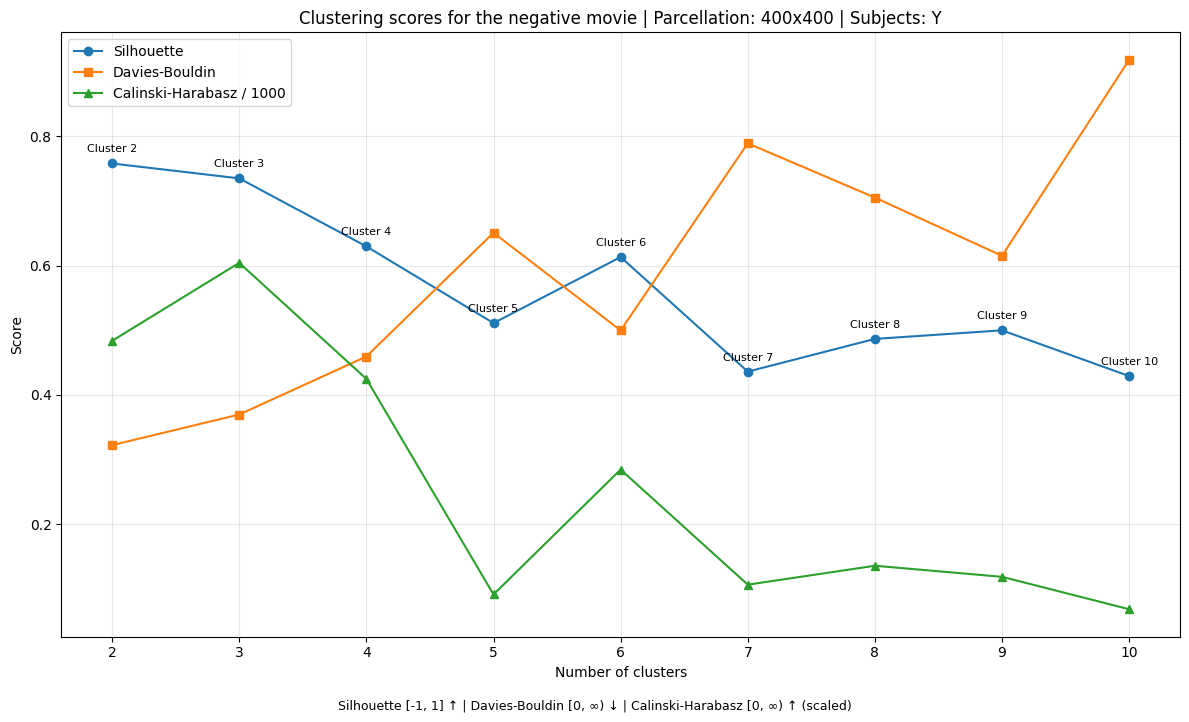

In [ ]:
# Print the clustering scores for all the runs 
from Evaluate_models_clean import plot_clustering_scores_sorted

model_dir = "Clusters"
model_prefix = "DCEC_400x400_71_"

# Silhouett score: Higher is better
# Calinski-Harabasz score: Lower is better
# Davies-Bouldin score: Higher is better
temp_results = plot_clustering_scores_sorted(
    models_dir=model_dir,
    model_prefix=model_prefix)


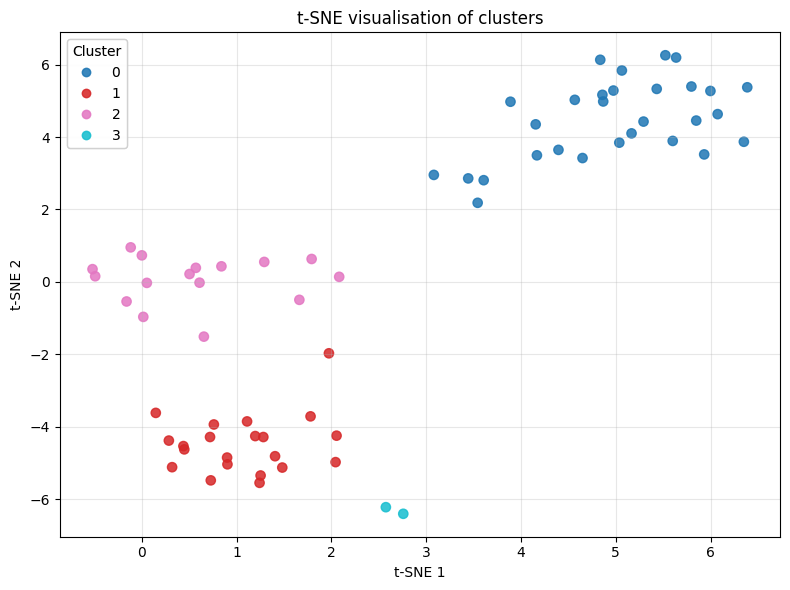

In [7]:
# T-sne for one clustering
from Evaluate_models_clean import plot_clustering

labels_path = "Clusters\\DCEC_400x400_68_O_subjects_run2_cluster_4_labels_predicted_labels_.txt"
middle_layer_path = "Clusters\\DCEC_400x400_68_O_subjects_run2_cluster_4_middle_layer_predicted_labels_.txt"

temp_results = plot_clustering(labels_path=labels_path, middle_layer_path=middle_layer_path)

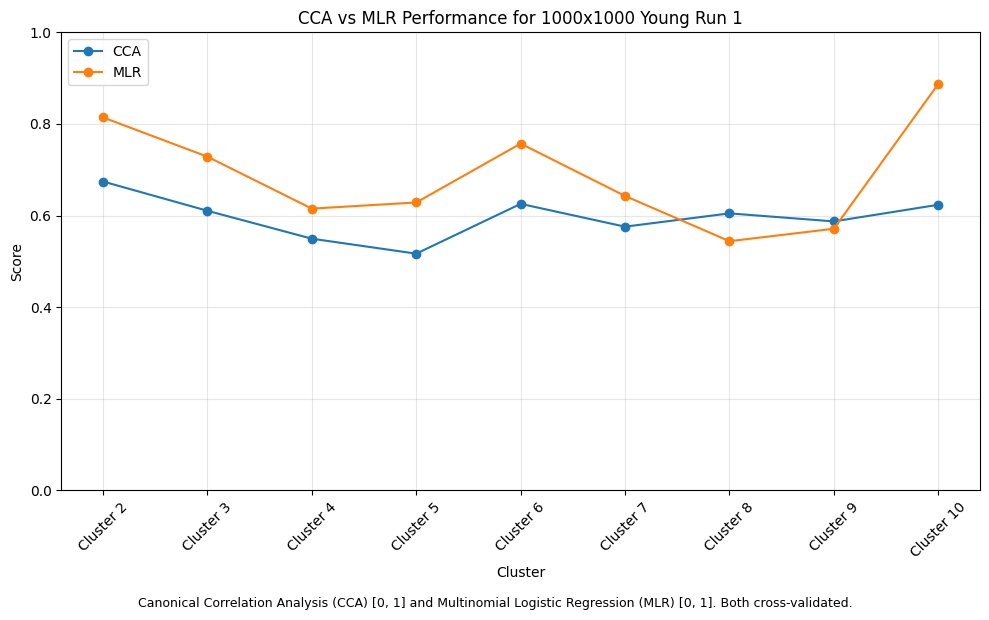

In [12]:
from Evaluate_models_clean import plot_cca_mlr_across_clusters

name = "1000x1000_Young_run1"
json_path = f"Results\\{name}_cluster_behavioural_results.json"

results = plot_cca_mlr_across_clusters(json_path, title="CCA vs MLR Performance for 1000x1000 Young Run 1")

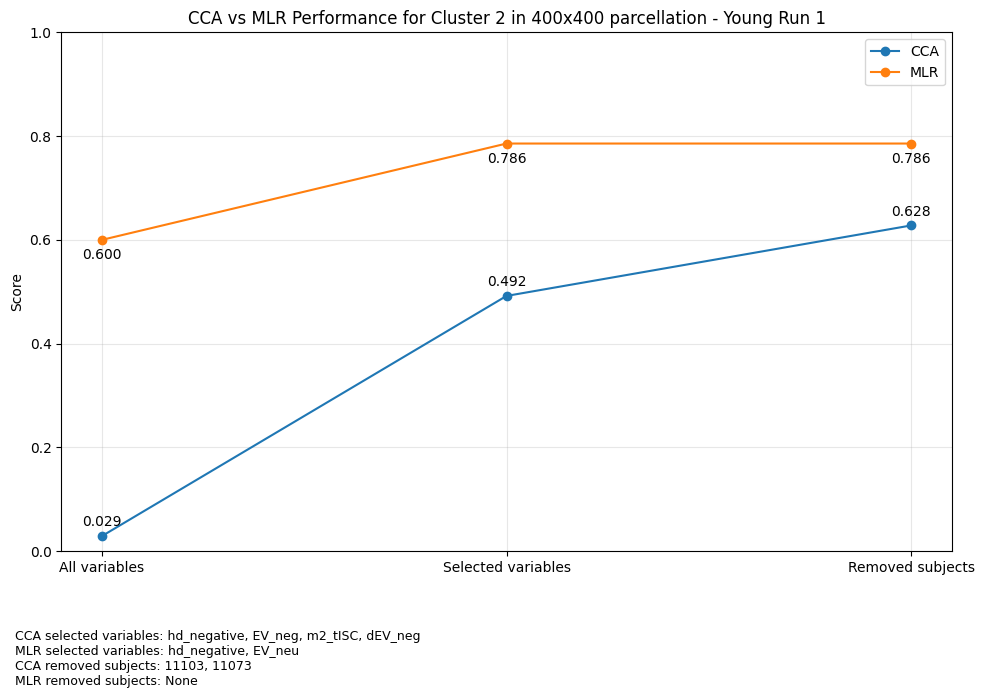

In [14]:
from Evaluate_models_clean import plot_single_cluster_cca_mlr_variants

json_path = "Results\\400x400_Young_run1_cluster_behavioural_results.json"
ideal_cluster_number = "2"  # Set this to the cluster number you want to plot
title = f"CCA vs MLR Performance for Cluster {ideal_cluster_number} in 400x400 parcellation - Young Run 1"

results = plot_single_cluster_cca_mlr_variants(json_path=json_path, cluster_number=ideal_cluster_number, title=title)

In [16]:
# Compare the common variables and removed subjects across clusters
from Evaluate_models_clean import compare_common_across_clusters, print_comparison_summary

file_id = "400x400_Young_run1"
json_path = rf"Results\\{file_id}_cluster_behavioural_results.json"
variable_keys = ["cca_selected_variables", "mlr_selected_variables"]
removed_subjects_keys = ["cca_removed_subjects", "mlr_removed_subjects"]

results_across_clusters = compare_common_across_clusters(json_path=json_path, variable_keys=variable_keys, removed_subjects_keys=removed_subjects_keys)
print_comparison_summary(results_across_clusters)


Comparison across clusters in: Results\\400x400_Young_run1_cluster_behavioural_results.json
Variable keys: ['cca_selected_variables', 'mlr_selected_variables']
Removed-subject keys: ['cca_removed_subjects', 'mlr_removed_subjects']

Common variables:
[]

Top 5 variable counts:
hd_negative: 7
Q2_DERSNONACCEPT: 3
m2_tISC: 3
rSFA: 3
ER_base: 2

Common removed subjects:
[]

Top 5 removed subject counts:
11037: 2
11042: 2
11073: 2
11078: 2
11103: 2


In [19]:
# Compare the common variables and removed subjects across same cluster
from Evaluate_models_clean import compare_common_across_runs_same_cluster, print_comparison_summary

Age = "Old"
cluster_number = "4"  # Set this to the cluster number you want to compare across runs

json_paths = [rf"Results\\1000x1000_{Age}_run1_cluster_behavioural_results.json", rf"Results\\{Age}_run1_cluster_behavioural_results.json",  rf"Results\\{Age}_run2_cluster_behavioural_results.json"]
variable_keys = ["cca_selected_variables", "mlr_selected_variables"]
removed_subjects_keys = ["cca_removed_subjects", "mlr_removed_subjects"]

results_across_same_cluster = compare_common_across_runs_same_cluster(json_paths=json_paths, variable_keys=variable_keys, removed_subjects_keys=removed_subjects_keys, cluster_number=cluster_number)
print_comparison_summary(results_across_same_cluster)


Comparison across runs for Cluster 4
Variable keys: ['cca_selected_variables', 'mlr_selected_variables']
Removed-subject keys: ['cca_removed_subjects', 'mlr_removed_subjects']

Common variables:
[]

Top 5 variable counts:
Q8Cog_em: 2
YearsEducation: 2
ER_base: 1
Order: 1
Q1_DASSStress: 1

Common removed subjects:
[12270, 12288]

Top 5 removed subject counts:
12270: 1
12288: 1


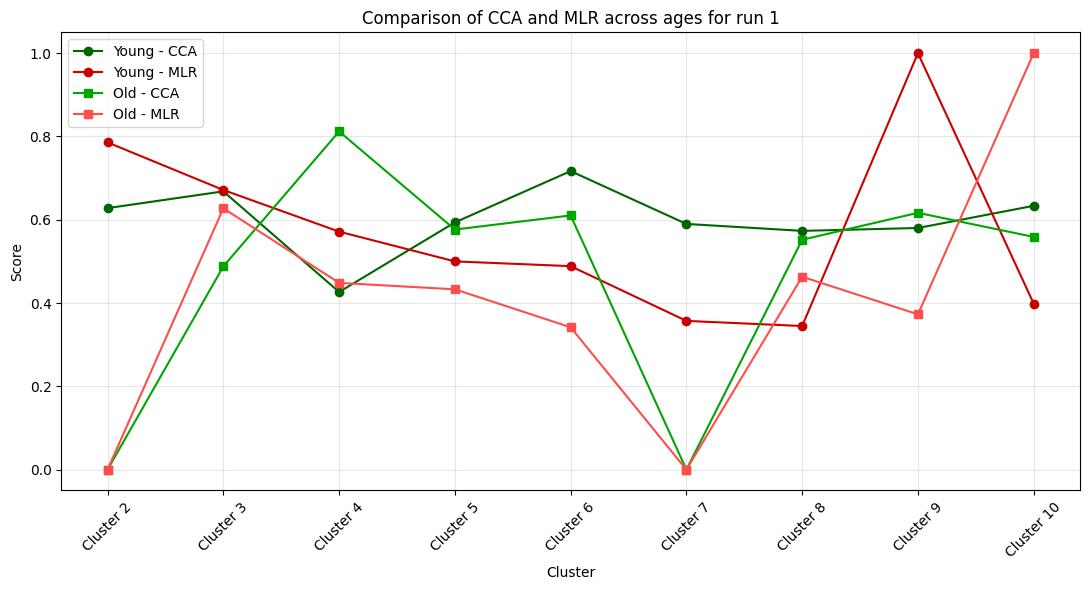

In [22]:
from Evaluate_models_clean import plot_cca_mlr_two_jsons_across_clusters

run_num = 1

young_path = rf"Results\\400x400_Young_run{run_num}_cluster_behavioural_results.json"
old_path = rf"Results\\400x400_Old_run{run_num}_cluster_behavioural_results.json"
title = rf"Comparison of CCA and MLR across ages for run {run_num}"

results = plot_cca_mlr_two_jsons_across_clusters(old_json_path=old_path, young_json_path=young_path, title=title)

Skipping non-matching JSON filename: Old_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Old_run2_cluster_behavioural_results.json
Skipping non-matching JSON filename: WRONG_1000x1000_Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run2_cluster_behavioural_results.json


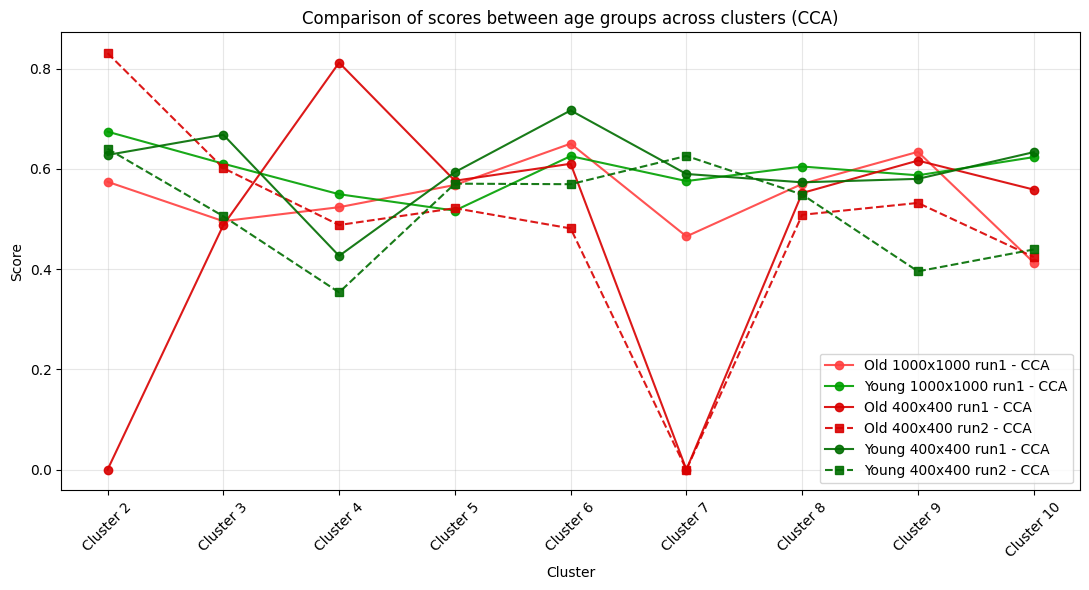

In [24]:
from Evaluate_models_clean import plot_compare_ages_across_clusters

save_path = rf"Figures\\Comparison young and old\\Compare_CCA_between_ages_across_clusters.png"
# "mlr_removed_subjects_results:mean_accuracy"
# "cca_removed_subjects_results:cv_mean_cc"
metric_to_use = "cca_removed_subjects_results:cv_mean_cc"

results = plot_compare_ages_across_clusters(metric_to_use=metric_to_use)

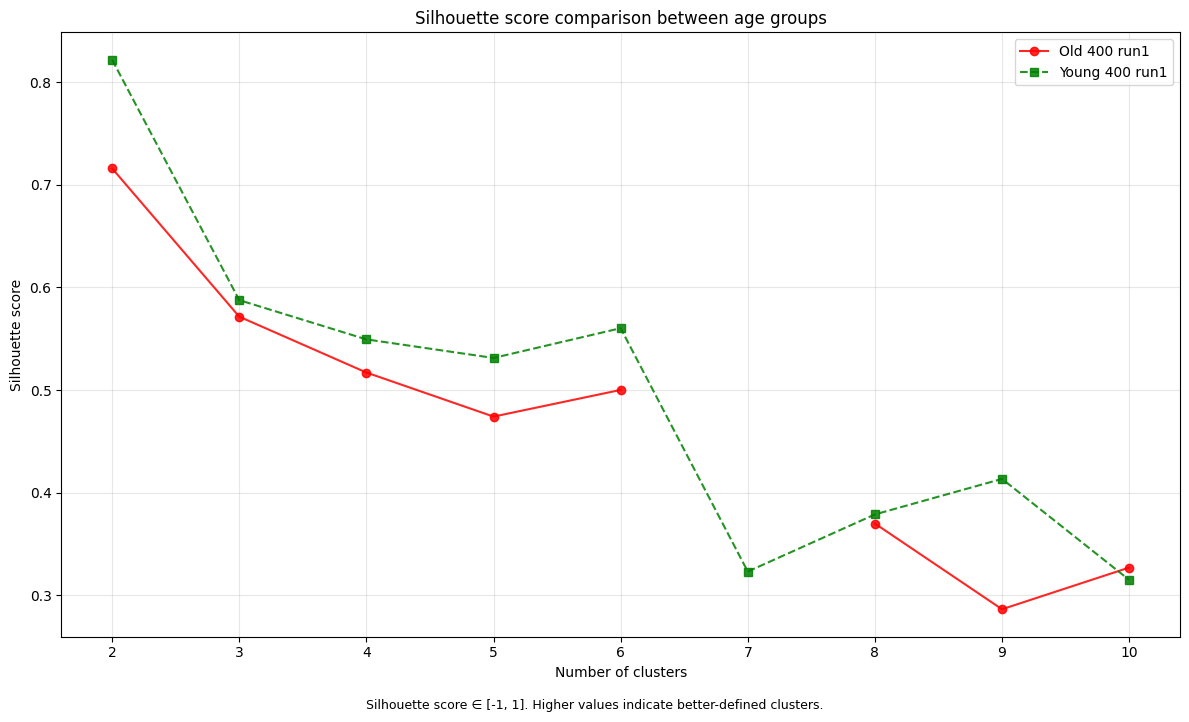

{'fig': <Figure size 1200x700 with 1 Axes>,
 'ax': <Axes: title={'center': 'Silhouette score comparison between age groups'}, xlabel='Number of clusters', ylabel='Silhouette score'>,
 'cluster_numbers': [2, 3, 4, 5, 6, 7, 8, 9, 10]}

In [31]:
from Evaluate_models_clean import collect_clustering_scores_from_folder, plot_silhouette_age_comparison

old_400_run1 = collect_clustering_scores_from_folder(
    models_dir="Clusters",
    model_prefix="DCEC_400x400_68_O_subjects_run1",
)

young_400_run1 = collect_clustering_scores_from_folder(
    models_dir="Clusters",
    model_prefix="DCEC_400x400_71_Y_subjects_run1",
)

plot_silhouette_age_comparison(
    run_results=[
        {"label": "Old 400 run1", "age_group": "Old", "results": old_400_run1},
        {"label": "Young 400 run1", "age_group": "Young", "results": young_400_run1},
    ],
)

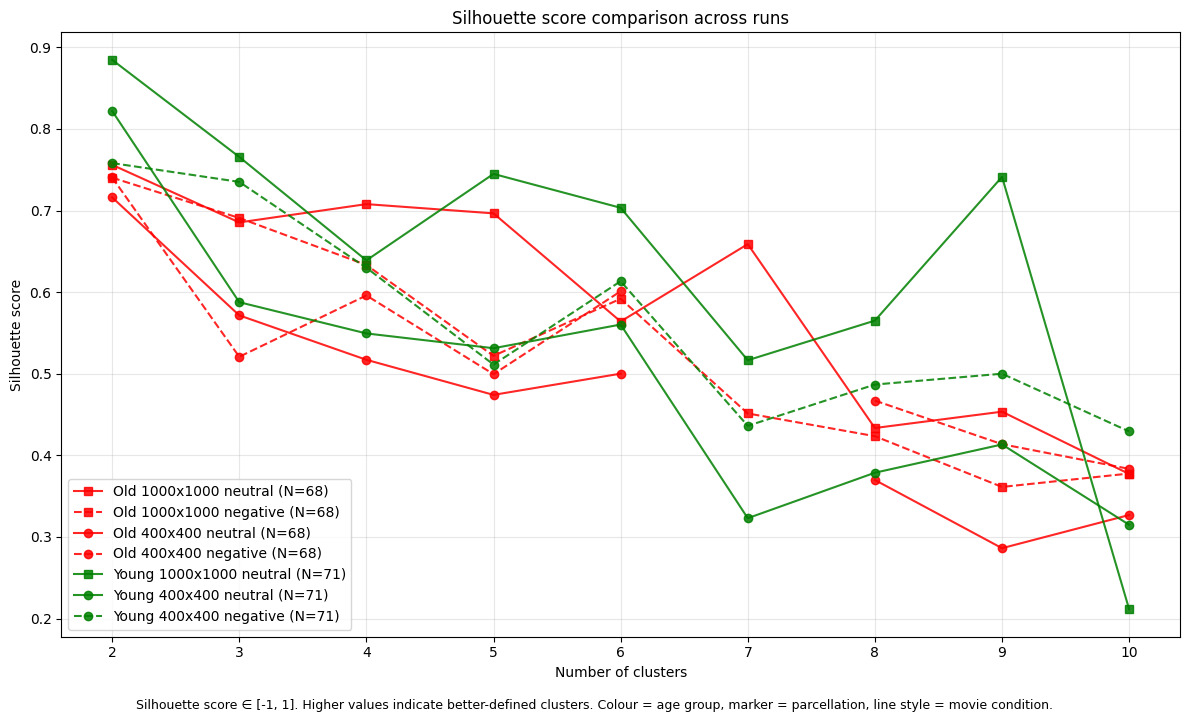

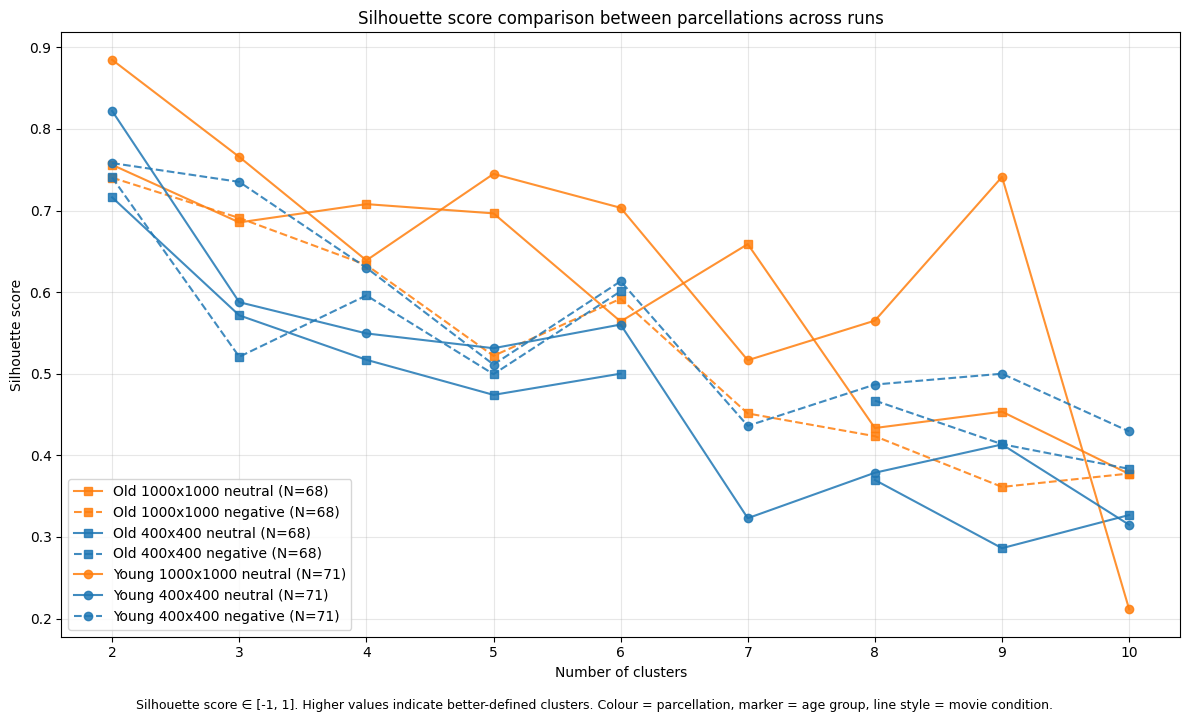

In [1]:
from Evaluate_models_clean import plot_silhouette_age_comparison_all_runs, plot_silhouette_parcellation_comparison_all_runs

models_dir = "Clusters"

temp_results = plot_silhouette_age_comparison_all_runs(models_dir=models_dir)
temp_results = plot_silhouette_parcellation_comparison_all_runs(models_dir=models_dir)

In [26]:
from Evaluate_models_clean import collect_cluster_rows, summarize_grouped
from pathlib import Path

JSON_DIR = Path("Results")

# This will read all files matching your naming convention:
# {parcellation}_{age group}_{movie number}_cluster_behavioural_results.json
json_paths = sorted(JSON_DIR.glob("*_cluster_behavioural_results.json"))

rows = collect_cluster_rows(json_paths)


# Count occurrences of variables across clusters and runs
cluster_summary = summarize_grouped(rows, group_keys=["cluster"], include_second=False)
print(f"Cluster Summary:\n{cluster_summary}\n")

Skipping non-matching JSON filename: Old_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Old_run2_cluster_behavioural_results.json
Skipping non-matching JSON filename: WRONG_1000x1000_Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run1_cluster_behavioural_results.json
Skipping non-matching JSON filename: Young_run2_cluster_behavioural_results.json
Cluster Summary:
   cluster  valid_cluster_solutions  \
0        2                        5   
1        3                        6   
2        4                        6   
3        5                        6   
4        6                        6   
5        7                        4   
6        8                        6   
7        9                        6   
8       10                        6   

                              most_frequent_variable  occurrences  
0                        Q2_DERSCLARITY; hd_negative            3  
1                           hd_negative

In [27]:
# Count occurrences shared by one movie condition group across ages
movie_summary = summarize_grouped(rows, group_keys=["movie"])
print(f"Movie Summary:\n{movie_summary}\n")

Movie Summary:
      movie  valid_cluster_solutions   most_frequent_variable  occurrences  \
0  negative                       17  Q3_GHQ28SomaticSymptoms            7   
1   neutral                       34              hd_negative           14   

  second_most_frequent_variable  second_occurrences  
0            Order; hd_negative                   6  
1                          rmet                  10  



In [28]:
# Count occurrences shared by one age group across their runs
age_summary = summarize_grouped(rows, group_keys=["age_group"])
print(f"Age Summary:\n{age_summary}\n")

Age Summary:
  age_group  valid_cluster_solutions    most_frequent_variable  occurrences  \
0       old                       24  Q3_GHQ28Anxiety_Insomnia            8   
1     young                       27               hd_negative           19   

                       second_most_frequent_variable  second_occurrences  
0  EV_neg; Q2_DERSNONACCEPT; Q2_DERSScore; Q8pers...                   6  
1                                     Q2_DERSCLARITY                   9  



In [29]:
# Count occurrences shared by one parcellation group across their runs
parcellation_summary = summarize_grouped(rows, group_keys=["parcellation"])
print(f"Parcellation Summary:\n{parcellation_summary}\n")

Parcellation Summary:
  parcellation  valid_cluster_solutions most_frequent_variable  occurrences  \
0    1000x1000                       18                   rmet            8   
1      400x400                       33            hd_negative           14   

  second_most_frequent_variable  second_occurrences  
0                   hd_negative                   6  
1                Q2_DERSCLARITY                   9  

